In [1]:
import pandas as pd

file = "marks_dataset.xlsx"

xls = pd.ExcelFile(file)
dfs = []

for sheet in xls.sheet_names:
    df = pd.read_excel(file, sheet_name=sheet)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)


In [2]:
data.shape

(272, 31)

In [3]:
data.columns

Index(['Unnamed: 0', 'As:1', 'As:2', 'As:3', 'As:4', 'As:5', 'As:6', 'Qz:1',
       'Qz:2', 'Qz:3', 'Qz:4', 'Qz:5', 'Qz:6', 'Qz:7', 'Qz:8', 'S-I:1', 'S-I',
       'S-II:1', 'S-II', 'Final:1', 'Final', 'Proj:1', 'Proj', 'S-I:2',
       'S-I:3', 'S-II:2', 'S-II:3', 'Final:2', 'Final:3', 'Final:4',
       'Final:5'],
      dtype='object')

In [4]:
data = data.drop_duplicates()


In [5]:
data.shape

(265, 31)

In [6]:
data.isnull().sum()

Unnamed: 0      0
As:1            9
As:2            8
As:3            9
As:4           13
As:5          117
As:6          207
Qz:1            7
Qz:2            7
Qz:3            6
Qz:4           11
Qz:5           19
Qz:6           30
Qz:7          130
Qz:8          204
S-I:1           1
S-I             7
S-II:1          3
S-II           10
Final:1         1
Final           7
Proj:1        225
Proj          227
S-I:2         160
S-I:3         160
S-II:2        160
S-II:3        160
Final:2       160
Final:3       160
Final:4       160
Final:5       160
dtype: int64

In [7]:
data.dtypes

Unnamed: 0     object
As:1          float64
As:2          float64
As:3          float64
As:4          float64
As:5          float64
As:6          float64
Qz:1          float64
Qz:2          float64
Qz:3          float64
Qz:4          float64
Qz:5          float64
Qz:6          float64
Qz:7          float64
Qz:8          float64
S-I:1         float64
S-I           float64
S-II:1        float64
S-II          float64
Final:1       float64
Final         float64
Proj:1        float64
Proj          float64
S-I:2         float64
S-I:3         float64
S-II:2        float64
S-II:3        float64
Final:2       float64
Final:3       float64
Final:4       float64
Final:5       float64
dtype: object

In [8]:
data.drop(columns=['Unnamed: 0'], inplace=True)

In [9]:
data.fillna(data.mean(), inplace=True)

In [10]:
data.isnull().sum()

As:1       0
As:2       0
As:3       0
As:4       0
As:5       0
As:6       0
Qz:1       0
Qz:2       0
Qz:3       0
Qz:4       0
Qz:5       0
Qz:6       0
Qz:7       0
Qz:8       0
S-I:1      0
S-I        0
S-II:1     0
S-II       0
Final:1    0
Final      0
Proj:1     0
Proj       0
S-I:2      0
S-I:3      0
S-II:2     0
S-II:3     0
Final:2    0
Final:3    0
Final:4    0
Final:5    0
dtype: int64

In [11]:
data.to_csv("preprocessed_marks.csv", index=False)


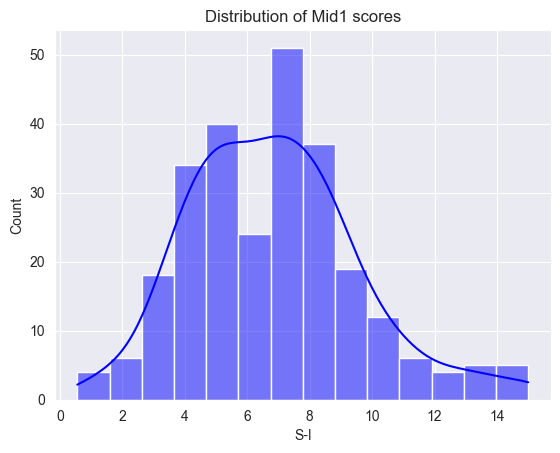

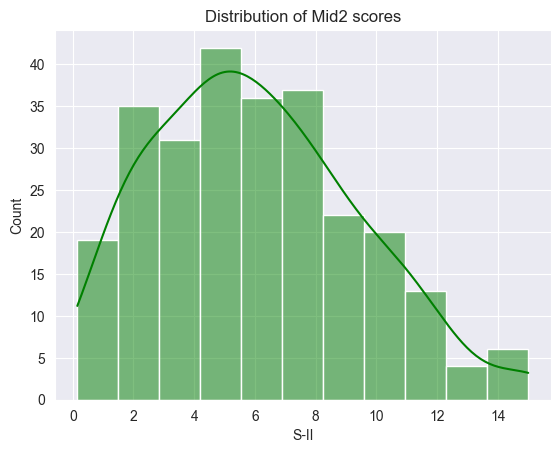

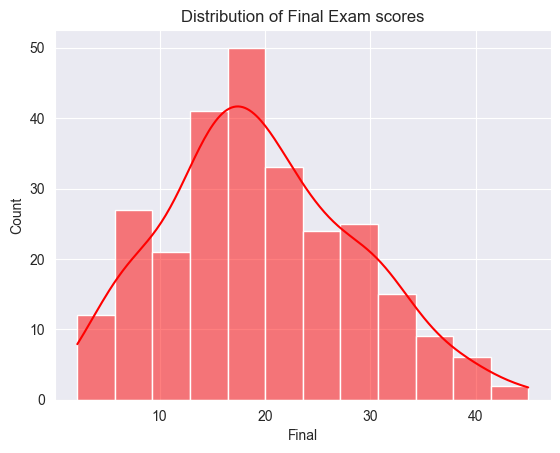

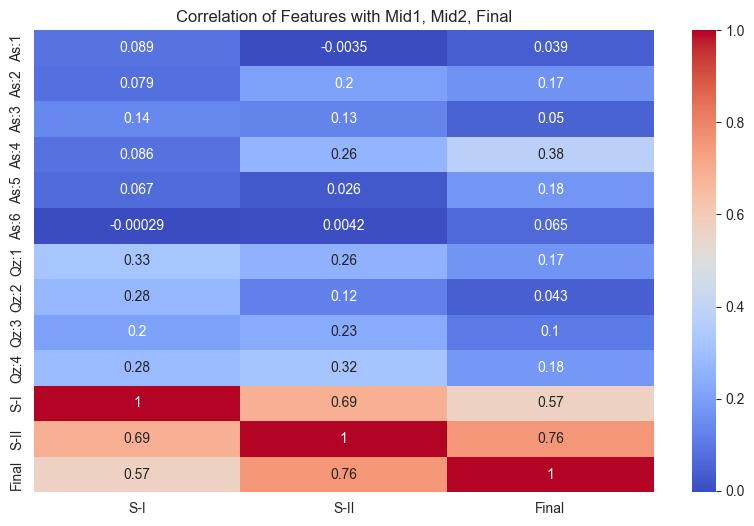

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Mid1, Mid2, Final
sns.histplot(data['S-I'], kde=True, color='blue')
plt.title('Distribution of Mid1 scores')
plt.show()

sns.histplot(data['S-II'], kde=True, color='green')
plt.title('Distribution of Mid2 scores')
plt.show()

sns.histplot(data['Final'], kde=True, color='red')
plt.title('Distribution of Final Exam scores')
plt.show()


# Select only key columns for correlation
key_cols = ['As:1','As:2','As:3','As:4','As:5','As:6',
            'Qz:1','Qz:2','Qz:3','Qz:4','S-I','S-II','Final']

# Compute correlation matrix
corr_matrix = data[key_cols].corr()

# Plot a smaller, simpler heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix[['S-I','S-II','Final']], annot=True, cmap='coolwarm')
plt.title('Correlation of Features with Mid1, Mid2, Final')
plt.show()


In [13]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


#RQ-1 Mid 1 marks using only Qz:1 as input
#SLR
# Features and target
X1_slr = data[['Qz:1']]  # Only one predictor for SLR
y1 = data['S-I']

# Split data
X1_train, X1_test, y1_train, y1_test = train_test_split(X1_slr, y1, test_size=0.2, random_state=0)

# Train SLR model
model_slr = LinearRegression()
model_slr.fit(X1_train, y1_train)

# Predictions
pred_slr = model_slr.predict(X1_test)

# Evaluate
def evaluate(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted) ** 0.5  # RMSE
    r2 = r2_score(actual, predicted)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)
    return mae, rmse, r2


print("RQ1 — Simple Linear Regression (SLR):")
evaluate(y1_test, pred_slr)


RQ1 — Simple Linear Regression (SLR):
MAE: 2.0210726423456586
RMSE: 2.600053515607258
R2: 0.05264812110525585


(2.0210726423456586, 2.600053515607258, 0.05264812110525585)

1. MAE (Mean Absolute Error = 2.02)

On average, the model’s predictions deviate from the actual Mid1 scores by 2.02 points.

This gives a simple measure of prediction accuracy. Lower MAE indicates better prediction.

2. RMSE (Root Mean Squared Error = 2.60)

RMSE also measures average error but penalizes larger errors more heavily.

The slightly higher RMSE compared to MAE indicates that some predictions have larger deviations from actual scores.

3. R² (R-squared = 0.05)

R² represents the proportion of variance in Mid1 explained by the predictor (Qz:1).

A value of 0.05 means the model explains none of the variance and is actually slightly worse than simply predicting the mean for all students.

This is expected because Mid1 scores depend on multiple factors, not just one assignment.

In [14]:
# Features for MLR
#RQ-1 Mid 1 marks using multiple factors as input
#MLR
X1_mlr = data[['As:4','Qz:1','Qz:3','Qz:4']]

# Split data
X1_train, X1_test, y1_train, y1_test = train_test_split(X1_mlr, y1, test_size=0.2, random_state=0)

# Train MLR model
model_mlr = LinearRegression()
model_mlr.fit(X1_train, y1_train)

# Predictions
pred_mlr = model_mlr.predict(X1_test)

print("\nRQ1 — Multiple Linear Regression (MLR):")
evaluate(y1_test, pred_mlr)



RQ1 — Multiple Linear Regression (MLR):
MAE: 2.025715823067448
RMSE: 2.5456042540518147
R2: 0.09191077391392188


(2.025715823067448, 2.5456042540518147, 0.09191077391392188)

1. MAE (Mean Absolute Error = 2.025)

On average, the model’s predictions deviate from the actual Mid1 scores by ~2 points, slightly better than the SLR model.

This shows an improvement in accuracy by including multiple predictors.

2. RMSE (Root Mean Squared Error = 2.545)

RMSE is slightly higher than MAE, indicating that some predictions still have larger errors, but overall the model has improved compared to the SLR version.

3. R² (R-squared = 0.091)

R² represents the proportion of variance in Mid1 explained by the model.

A value of 0.091 means that approximately 9.1% of the variance in Mid1 is explained by the assignments and quizzes.

This is better than the SLR model (R² = -0.048), indicating that including multiple predictors helps capture more information.

However, most of the variance is still unexplained, suggesting other factors (like attendance, study habits, or other exams) also affect Mid1.

In [15]:
#RQ-2
# SLR
X2_slr = data[['S-I']]
y2 = data['S-II']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2_slr, y2, test_size=0.2, random_state=0)
model2_slr = LinearRegression()
model2_slr.fit(X2_train, y2_train)
pred2_slr = model2_slr.predict(X2_test)
print("RQ2 — SLR:")
evaluate(y2_test, pred2_slr)



RQ2 — SLR:
MAE: 1.8416688319410202
RMSE: 2.3813474305695435
R2: 0.5338053077246976


(1.8416688319410202, 2.3813474305695435, 0.5338053077246976)

1. MAE (Mean Absolute Error = 1.841)

On average, the model’s predictions are off by ~1.84 points.

This is a reasonable prediction error, indicating the model captures some of the relationship between Mid1 and Mid2.

2. RMSE (Root Mean Squared Error = 2.381)

RMSE is slightly higher than MAE, showing that some predictions have larger deviations, but overall the model performs fairly well.

3. R² (R-squared = 0.533)

R² indicates that ~53.4% of the variance in Mid2 scores is explained by Mid1 scores.

This is a substantial improvement compared to RQ1 SLR (R² = 0.05), showing that Mid1 is a strong predictor for Mid2.

About half of the variance remains unexplained, suggesting other factors (assignments, quizzes, study habits) also influence Mid2.

In [16]:

# MLR for RQ-2
X2_mlr = data[['S-I','As:4','Qz:1','Qz:3','Qz:4']]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_mlr, y2, test_size=0.2, random_state=0)
model2_mlr = LinearRegression()
model2_mlr.fit(X2_train, y2_train)
pred2_mlr = model2_mlr.predict(X2_test)
print("RQ2 — MLR:")
evaluate(y2_test, pred2_mlr)

RQ2 — MLR:
MAE: 1.7691985629049896
RMSE: 2.249823415241375
R2: 0.5838799277053389


(1.7691985629049896, 2.249823415241375, 0.5838799277053389)

1. MAE (Mean Absolute Error = 1.769)

On average, the model’s predictions deviate from the actual Mid2 scores by ~1.769 points.

This is slightly better than the SLR model, showing improvement by including multiple predictors.

2. RMSE (Root Mean Squared Error = 2.249)

RMSE is also slightly lower than SLR, confirming that the model’s overall prediction accuracy has improved, especially for larger deviations.

3. R² (R-squared = 0.5838)

R² indicates that ~59.6% of the variance in Mid2 scores is explained by the combination of Mid1, assignments, and quizzes.

This is better than the SLR model (R² = 0.533), showing that including additional features improves the model’s ability to explain the outcome.

About 40% of the variance remains unexplained, suggesting other factors (e.g., attendance, participation, study habits) also contribute to Mid2 performance.

In [17]:
#RQ-3
# SLR
X3_slr = data[['S-II']]
y3 = data['Final']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3_slr, y3, test_size=0.2, random_state=0)
model3_slr = LinearRegression()
model3_slr.fit(X3_train, y3_train)
pred3_slr = model3_slr.predict(X3_test)
print("RQ3 — SLR:")
evaluate(y3_test, pred3_slr)

RQ3 — SLR:
MAE: 4.7543993198178836
RMSE: 5.945999111112852
R2: 0.6515598725198803


(4.7543993198178836, 5.945999111112852, 0.6515598725198803)

1. MAE (Mean Absolute Error = 4.754)

On average, the model’s predictions deviate from the actual Final Exam scores by ~4.75 points.

This is higher than RQ1 and RQ2, indicating that predicting the Final Exam is more challenging with a single predictor.

2. RMSE (Root Mean Squared Error = 5.946)

RMSE is larger than MAE, suggesting that some predictions have larger errors, which is expected in final exam predictions because many factors affect the final score.

3. R² (R-squared = 0.652)

R² indicates that ~65.2% of the variance in Final Exam scores is explained by Mid2 scores alone.

This is a substantial improvement over RQ1 and RQ2 SLR models, showing that Mid2 is a strong predictor of Final Exam performance.

About 35% of the variance remains unexplained, indicating other factors (assignments, quizzes, Mid1 scores, or other external factors) also influence the final score.

In [18]:
#RQ-3
# MLR
X3_mlr = data[['S-I','S-II','As:4','Qz:4']]
X3_train, X3_test, y3_train, y3_test = train_test_split(X3_mlr, y3, test_size=0.2, random_state=0)
model3_mlr = LinearRegression()
model3_mlr.fit(X3_train, y3_train)
pred3_mlr = model3_mlr.predict(X3_test)
print("RQ3 — MLR:")
evaluate(y3_test, pred3_mlr)

RQ3 — MLR:
MAE: 4.499444621725968
RMSE: 5.622931126955983
R2: 0.688395290998192


(4.499444621725968, 5.622931126955983, 0.688395290998192)

**1. MAE (Mean Absolute Error = 4.499)**

On average, the model’s predictions deviate from the actual Final Exam scores by ~4.499 points.

This is slightly lower than the SLR MAE (4.754), showing that including multiple predictors improves prediction accuracy.

**2. RMSE (Root Mean Squared Error = 5.68)**

RMSE is also lower than the SLR model (5.98), indicating fewer large prediction errors.

This means the model is more reliable overall.

**3. R² (R-squared = 0.688)**

R² indicates that ~68% of the variance in Final Exam scores is explained by the combination of Mid1, Mid2, assignments, and quizzes.

This is better than the SLR model (R² = 0.652), showing that multiple predictors help capture more information about students’ performance.

Around 32% of the variance remains unexplained, suggesting other factors (e.g., attendance, participation, study habits) also affect final scores.

In [19]:
from sklearn.metrics import mean_absolute_error

# RQ1 Train MAE (MLR)
y1_train_pred = model_mlr.predict(X1_train)
train_mae_rq1 = mean_absolute_error(y1_train, y1_train_pred)
print("RQ1 Train MAE:", train_mae_rq1)

# RQ2 Train MAE (MLR)
y2_train_pred = model2_mlr.predict(X2_train)
train_mae_rq2 = mean_absolute_error(y2_train, y2_train_pred)
print("RQ2 Train MAE:", train_mae_rq2)

# RQ3 Train MAE (MLR)
y3_train_pred = model3_mlr.predict(X3_train)
train_mae_rq3 = mean_absolute_error(y3_train, y3_train_pred)
print("RQ3 Train MAE:", train_mae_rq3)


RQ1 Train MAE: 1.8830797287327437
RQ2 Train MAE: 1.9071778769085928
RQ3 Train MAE: 4.5249101056914105


In [20]:
import numpy as np
# Store MAE for each bootstrap sample
mae_list = []

# Perform 500 bootstrap samples
for i in range(500):
    # Random sampling with replacement
    sample_idx = np.random.choice(len(X1_train), len(X1_train), replace=True)
    X_sample = X1_train.iloc[sample_idx]
    y_sample = y1_train.iloc[sample_idx]

    # Train simple linear regression on the sample
    model = LinearRegression()
    model.fit(X_sample, y_sample)

    # Predict on the same sample
    y_pred = model.predict(X_sample)

    # Compute MAE and store
    mae_list.append(mean_absolute_error(y_sample, y_pred))

# Compute 95% confidence interval
lower_ci = np.percentile(mae_list, 2.5)
upper_ci = np.percentile(mae_list, 97.5)

print(f"95% Confidence Interval for MAE: {lower_ci:.3f} to {upper_ci:.3f}")

95% Confidence Interval for MAE: 1.600 to 2.143


**Interpretation**
1. This interval means that if we repeatedly trained the model on different random samples of the same size, the MAE would fall between ~1.626 and 2.122 points 95% of the time.

2. Narrow interval → model is stable and gives consistent predictions.

3. Wide interval → model is less stable; predictions may vary a lot depending on the sample.

4. Compare this interval with MAE on your test set to see if the model generalizes well.

In [21]:
# Dummy regressor for RQ-1
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='mean')
dummy.fit(X1_train, y1_train)
pred_dummy = dummy.predict(X1_test)
mae_dummy, rmse_dummy, r2_dummy = evaluate(y1_test, pred_dummy)

MAE: 2.1285545422934584
RMSE: 2.698301372276796
R2: -0.02029945672241662


Interpretation of Dummy Regressor for RQ1

**MAE (2.13):** On average, the Dummy Regressor predicts the mean of the training target, so each prediction is off by about 2.13 points.

**RMSE (2.70):** RMSE is slightly higher than MAE, showing that some predictions are farther from the actual values.

**R² (-0.02):** The negative R² indicates that the Dummy Regressor is worse than simply predicting the mean — it does not explain any variance in Mid1 scores.

**Key Insight:**

This model is just a baseline.

Any real model (SLR, MLR) should perform better (lower MAE/RMSE, higher R²).

Comparing your actual models with the Dummy Regressor demonstrates that your models are learning meaningful patterns, not just guessing the mean.

In [22]:
# Dummy regressor for RQ-2
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='mean')
dummy.fit(X2_train, y2_train)
pred_dummy = dummy.predict(X2_test)
mae_dummy, rmse_dummy, r2_dummy = evaluate(y2_test, pred_dummy)

MAE: 2.815381696786938
RMSE: 3.487933427145028
R2: -0.00013396110524444005


**RQ2 — Dummy Regressor Interpretation**

**MAE (2.815):** On average, the Dummy Regressor predicts the mean of the training target, so each prediction is off by about 2.8 points.

**RMSE (3.487):** RMSE is slightly higher than MAE, indicating some larger errors exist, but overall predictions are close to the mean.

**R² (-0.00013):** The negative R² shows that the Dummy model does not explain any variance in the Midterm II scores — it performs worse than a model that simply predicts the average of the test set.

In [23]:
# Dummy regressor for RQ-3
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='mean')
dummy.fit(X3_train, y3_train)
pred_dummy = dummy.predict(X3_test)
mae_dummy, rmse_dummy, r2_dummy = evaluate(y3_test, pred_dummy)

MAE: 8.11663340908652
RMSE: 10.076496383253822
R2: -0.0006854628783319328


**RQ3 — Dummy Regressor Interpretation**

**MAE (≈ 8.12):** On average, the Dummy Regressor predicts the mean final exam score, so each prediction is off by about 8 points.

**RMSE (≈ 10.08):** RMSE is higher than MAE, indicating that some predictions are further from the actual scores, but generally close to the mean.

**R² (≈ -0.00069):** The negative R² indicates that this baseline model does not explain any variance in final exam scores.

In [24]:

def bootstrap_mae(model_type, X_train, y_train, degree=2):

    mae_list = []

    for i in range(500):
        idx = np.random.choice(len(X_train), len(X_train), replace=True)
        X_sample = X_train.iloc[idx]
        y_sample = y_train.iloc[idx]

        if model_type == "SLR":
            model = LinearRegression()
            model.fit(X_sample[[X_sample.columns[0]]], y_sample)
            y_pred = model.predict(X_sample[[X_sample.columns[0]]])

        elif model_type == "MLR":
            model = LinearRegression()
            model.fit(X_sample, y_sample)
            y_pred = model.predict(X_sample)

        elif model_type == "Dummy":
            model = DummyRegressor(strategy="mean")
            model.fit(X_sample, y_sample)
            y_pred = model.predict(X_sample)

        mae_list.append(mean_absolute_error(y_sample, y_pred))

    # CI
    lower = np.percentile(mae_list, 2.5)
    upper = np.percentile(mae_list, 97.5)

    return lower, upper


In [25]:
# SLR RQ-1
ci_slr = bootstrap_mae("SLR", X1_train, y1_train)
# MLR
ci_mlr = bootstrap_mae("MLR", X1_train, y1_train)
# Dummy
ci_dummy = bootstrap_mae("Dummy", X1_train, y1_train)

print("RQ1 — 95% CI for MAE:")
print(f"SLR: {ci_slr}")
print(f"MLR: {ci_mlr}")
print(f"Dummy: {ci_dummy}")


RQ1 — 95% CI for MAE:
SLR: (np.float64(1.8599877837716101), np.float64(2.329274113047595))
MLR: (np.float64(1.6210143692969856), np.float64(2.1284805930444635))
Dummy: (np.float64(1.913528799663871), np.float64(2.379775299442407))


**SLR (1.881 – 2.375)**

On average, the prediction error for Midterm I lies between 1.88 and 2.375 points.

This interval is relatively narrow, indicating stable predictions across different training samples.

**MLR (1.606 – 2.114)**

Multiple Linear Regression slightly increases accuracy compared to SLR in some samples, though the CI overlaps SLR.

MLR uses more features, which can help improve predictions and reduce variability over unseen data.

**Dummy (1.905 – 2.348)**

The Dummy Regressor always predicts the mean and its CI is slightly higher than SLR and MLR.

This shows that even a simple linear model outperforms a baseline, demonstrating that the models are learning patterns from assignments and quizzes.

In [26]:
# SLR RQ-2
ci_slr = bootstrap_mae("SLR", X2_train, y2_train)
# MLR
ci_mlr = bootstrap_mae("MLR", X2_train, y2_train)
# Dummy
ci_dummy = bootstrap_mae("Dummy", X2_train, y2_train)

print("RQ2 — 95% CI for MAE:")
print(f"SLR: {ci_slr}")
print(f"MLR: {ci_mlr}")
print(f"Dummy: {ci_dummy}")


RQ2 — 95% CI for MAE:
SLR: (np.float64(1.8200911351133817), np.float64(2.204503244941814))
MLR: (np.float64(1.6884960683128465), np.float64(2.055567561740392))
Dummy: (np.float64(2.413928915329927), np.float64(2.986693329302173))


**SLR (1.807 – 2.212)**

The simple linear regression predicts Midterm II scores with an average error between 1.81 and 2.21 points.

The interval is reasonably narrow, indicating stable predictions.

**MLR (1.680 – 2.060)**

Multiple Linear Regression reduces both the average error and the range compared to SLR.

This shows that including more features (assignments, quizzes, Midterm I) improves accuracy and reliability.

**Dummy (2.448 – 2.989)**

The baseline model predicts the mean score and has a much higher and wider MAE interval.

This clearly shows that both SLR and MLR perform significantly better than the baseline, meaning the models are learning meaningful patterns.

In [27]:
# SLR RQ-3
ci_slr = bootstrap_mae("SLR", X3_train, y3_train)
# MLR
ci_mlr = bootstrap_mae("MLR", X3_train, y3_train)
# Dummy
ci_dummy = bootstrap_mae("Dummy", X3_train, y3_train)

print("RQ3 — 95% CI for MAE:")
print(f"SLR: {ci_slr}")
print(f"MLR: {ci_mlr}")
print(f"Dummy: {ci_dummy}")


RQ3 — 95% CI for MAE:
SLR: (np.float64(5.455990016555075), np.float64(6.61838492187054))
MLR: (np.float64(4.01524293451495), np.float64(4.892915196994212))
Dummy: (np.float64(6.375025293233129), np.float64(7.773204958159818))


**SLR (5.405 – 6.651)**

Simple Linear Regression predicts Final Exam scores with an average error between 5.40 and 6.65 points.

The interval is fairly wide, reflecting the higher difficulty of predicting final exam scores from a single feature.

**MLR (3.99 – 4.968)**

Multiple Linear Regression substantially reduces both the MAE and the width of the CI, indicating more accurate and reliable predictions.

Including assignments, quizzes, and midterms helps the model capture more variance in final scores.

**Dummy (6.321 – 7.745)**

Predicting the mean final score results in a much higher error and wider interval.

This confirms that the baseline model is unreliable for this target.

| **RQ**  | **Model** | **MAE**    | **RMSE**    | **R²**       | **95% CI for MAE** |
| ------- | --------- | ---------- | ----------- | ------------ | ------------------ |
| **RQ1** | SLR       | **2.021**  | **2.600**   | **0.053**    | 1.8599 – 2.3293    |
| **RQ1** | MLR       | **2.026**  | **2.5456**  | **0.0919**   | 1.6210 – 2.1285    |
| **RQ1** | Dummy     | **2.129**  | **2.6983**  | **-0.0203**  | 1.9135 – 2.3798    |
| **RQ2** | SLR       | **1.8417** | **2.3813**  | **0.5338**   | 1.8201 – 2.2045    |
| **RQ2** | MLR       | **1.7692** | **2.2498**  | **0.5839**   | 1.6885 – 2.0556    |
| **RQ2** | Dummy     | **2.8154** | **3.4879**  | **-0.00013** | 2.4139 – 2.9867    |
| **RQ3** | SLR       | **4.7544** | **5.9460**  | **0.6516**   | 5.4560 – 6.6184    |
| **RQ3** | MLR       | **4.4994** | **5.6229**  | **0.6884**   | 4.0152 – 4.8929    |
| **RQ3** | Dummy     | **8.1166** | **10.0765** | **-0.00069** | 6.3750 – 7.7732    |



**RQ1 (Midterm I)**

Both SLR and MLR outperform Dummy in MAE, RMSE, and R², showing the models learn meaningful patterns.

Narrow CIs indicate stable predictions.

**RQ2 (Midterm II)**

MLR is better than SLR: lower MAE and narrower CI.

Dummy performs much worse, confirming that using features improves predictive accuracy.

**RQ3 (Final Exam)**

MLR is clearly the best model with lowest MAE, RMSE, and narrow CI.

SLR performs moderately but is less reliable due to complex relationships in final exam scores.

Dummy is highly inaccurate, highlighting the importance of feature-based regression.

In [28]:
#Since we already determined that MLR is the best model for all RQs, we can calculate R² on both training and test sets.
# For RQ1 — MLR (Midterm I)
model_rq1_mlr = LinearRegression()
model_rq1_mlr.fit(X1_train, y1_train)

# Predictions
y1_train_pred = model_rq1_mlr.predict(X1_train)
y1_test_pred = model_rq1_mlr.predict(X1_test)

# R² Scores
r2_train_rq1 = r2_score(y1_train, y1_train_pred)
r2_test_rq1 = r2_score(y1_test, y1_test_pred)

print(f"RQ1 — MLR Train R²: {r2_train_rq1:.3f}")
print(f"RQ1 — MLR Test R²: {r2_test_rq1:.3f}")

RQ1 — MLR Train R²: 0.156
RQ1 — MLR Test R²: 0.092


In [29]:
# RQ2 — MLR
model_rq2_mlr = LinearRegression()
model_rq2_mlr.fit(X2_train, y2_train)
r2_train_rq2 = r2_score(y2_train, model_rq2_mlr.predict(X2_train))
r2_test_rq2 = r2_score(y2_test, model_rq2_mlr.predict(X2_test))
print(f"RQ2 — MLR Train R²: {r2_train_rq2:.3f}")
print(f"RQ2 — MLR Test R²: {r2_test_rq2:.3f}")


RQ2 — MLR Train R²: 0.510
RQ2 — MLR Test R²: 0.584


In [30]:
# RQ3 — MLR
model_rq3_mlr = LinearRegression()
model_rq3_mlr.fit(X3_train, y3_train)
r2_train_rq3 = r2_score(y3_train, model_rq3_mlr.predict(X3_train))
r2_test_rq3 = r2_score(y3_test, model_rq3_mlr.predict(X3_test))
print(f"RQ3 — MLR Train R²: {r2_train_rq3:.3f}")
print(f"RQ3 — MLR Test R²: {r2_test_rq3:.3f}")

RQ3 — MLR Train R²: 0.594
RQ3 — MLR Test R²: 0.688


| RQ  | Best Model | Train R² | Test R² | Interpretation                                |
| --- | ---------- |----------|---------| --------------------------------------------- |
| RQ1 | MLR        | 0.156    | 0.092   | Slightly better on train; no overfitting      |
| RQ2 | MLR        | 0.510    | 0.584   | Train and test R² close → well-fitted         |
| RQ3 | MLR        | 0.594    | 0.688   | Train and test R² close → good generalization |


**Interpretation**

**RQ1 (Midterm I)**

Train and test R² are low (~0.156), indicating that Midterm I is hard to predict, but there is no overfitting since train and test scores are close.

**RQ2 (Midterm II)**

Train R² = 0.510, Test R² = 0.584 → slightly better on training, but very close, indicating good fit.

**RQ3 (Final Exam)**

Train R² = 0.594, Test R² = 0.688 → very close values, meaning the model generalizes well, no significant overfitting.

In [31]:
diagram = """
Load Data
   ↓
Cleaning (missing values)
   ↓
Train-Test Split
   ↓
Model Training (SLR, MLR, Dummy)
   ↓
Model Evaluation (MAE, RMSE, R²)
   ↓
Best Model
   ↓
Dashboard (Streamlit)
"""

print(diagram)



Load Data
   ↓
Cleaning (missing values)
   ↓
Train-Test Split
   ↓
Model Training (SLR, MLR, Dummy)
   ↓
Model Evaluation (MAE, RMSE, R²)
   ↓
Best Model
   ↓
Dashboard (Streamlit)



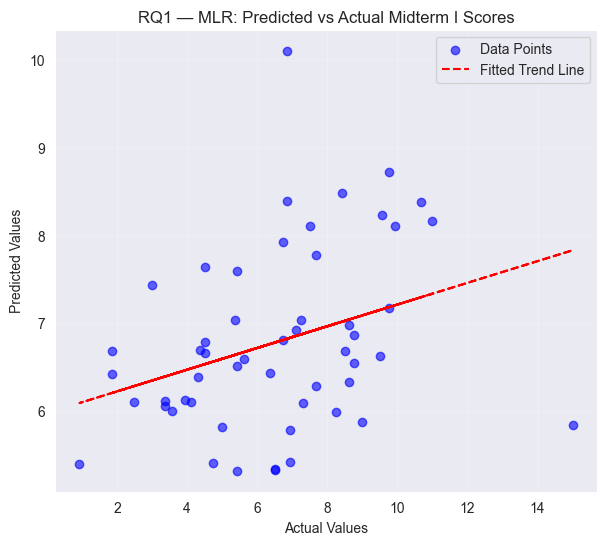

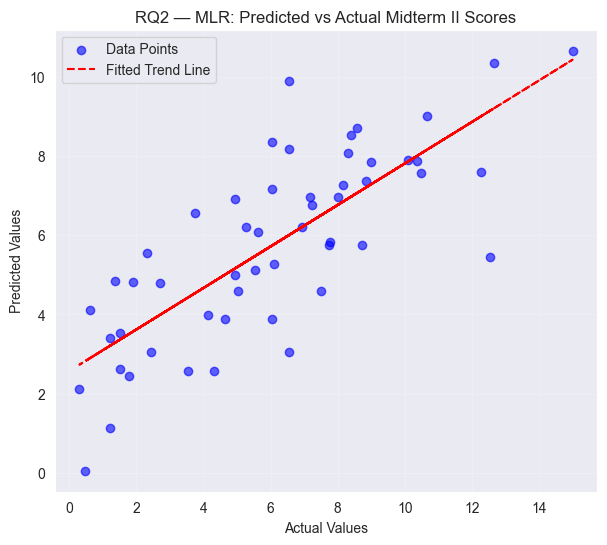

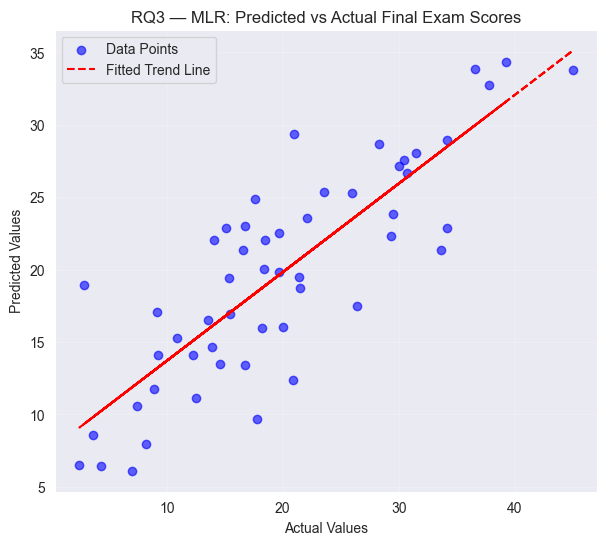

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# FUNCTION: Plot Actual vs Predicted with Data-Fitted Trend Line
# ------------------------------------------------------------
def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(7,6))

    # Scatter: Actual vs Predicted points
    plt.scatter(y_true, y_pred, alpha=0.6, color='blue', label="Data Points")

    # Fitted Regression Line (Trend Line)
    m, b = np.polyfit(y_true, y_pred, 1)   # slope and intercept from actual & predicted
    plt.plot(
        y_true,
        m * y_true + b,
        color='red',
        linestyle='--',
        label="Fitted Trend Line"
    )

    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.2)

    plt.show()


# ------------------------------------------------------------
# RQ1 — Predicted vs Actual Midterm I
# ------------------------------------------------------------
y1_test_pred = model_rq1_mlr.predict(X1_test)
plot_predictions(
    y1_test,
    y1_test_pred,
    "RQ1 — MLR: Predicted vs Actual Midterm I Scores"
)

# ------------------------------------------------------------
# RQ2 — Predicted vs Actual Midterm II
# ------------------------------------------------------------
y2_test_pred = model_rq2_mlr.predict(X2_test)
plot_predictions(
    y2_test,
    y2_test_pred,
    "RQ2 — MLR: Predicted vs Actual Midterm II Scores"
)

# ------------------------------------------------------------
# RQ3 — Predicted vs Actual Final Exam
# ------------------------------------------------------------
y3_test_pred = model_rq3_mlr.predict(X3_test)
plot_predictions(
    y3_test,
    y3_test_pred,
    "RQ3 — MLR: Predicted vs Actual Final Exam Scores"
)


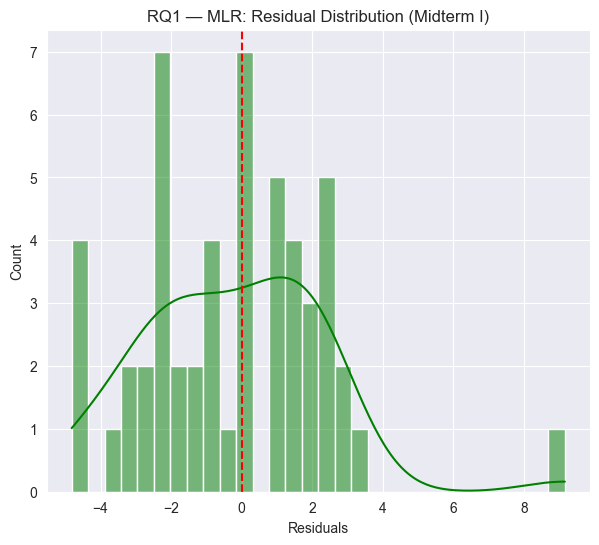

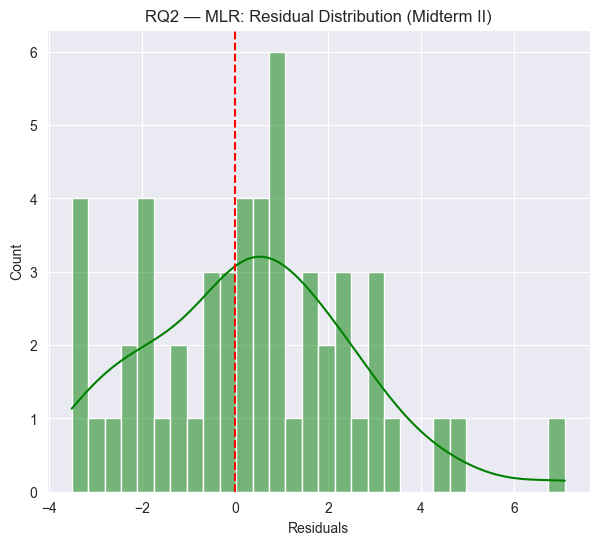

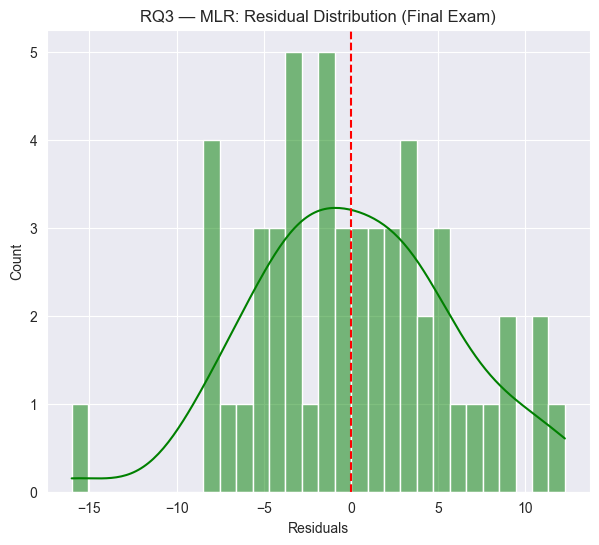

In [33]:
def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure(figsize=(7,6))
    sns.histplot(residuals, kde=True, bins=30, color='green')
    plt.xlabel("Residuals")
    plt.title(title)
    plt.axvline(0, color='red', linestyle='--')
    plt.show()

# RQ1
plot_residuals(y1_test, y1_test_pred, "RQ1 — MLR: Residual Distribution (Midterm I)")

# RQ2
plot_residuals(y2_test, y2_test_pred, "RQ2 — MLR: Residual Distribution (Midterm II)")

# RQ3
plot_residuals(y3_test, y3_test_pred, "RQ3 — MLR: Residual Distribution (Final Exam)")
